In [1]:
%help

The following SysML v2 magic commands are available.
For help on a specific command, use "%help <COMMAND>" or "%<cmd> -h".

%eval		Evaluate a given expression.
%export		Save a file of the JSON representation of the abstract syntax tree rooted in the named element.
%help		Get a list of available commands or help on a specific command
%list		List loaded library packages or the results of a given query
%load		Load models from the repository
%projects	List projects in the repository
%publish	Publish to the repository the model elements rooted in a named element
%repo		Set the API base path for the repository
%show		Print the abstract syntax tree rooted in a named element
%view		Render the view specified by the named view usage
%viz		Visualize the named model elements


In [24]:
%eval -h

Usage: %eval [--target=<NAME>] <EXPR>

Print the results of evaluating <EXPR> on the target given by <NAME>, which must be fully qualified.
If a target is not given, then evaluate <EXPR> in global scope.


In [9]:
%viz -h

Usage: %viz [--view=<VIEW>] [--style=<STYLE>...] <NAME> [<NAME>...]

Visualize model elements of <NAME>(s). <NAME>s must be fully qualified.

<VIEW> is case insensitive and possible candidates are:
   DEFAULT		Automatically choose an appropriate view from the given model element names
   TREE			Show a tree-structural view, like a Block Definition Diagram (BDD)
   INTERCONNECTION	Show an interconnection view, like an Internal Block Diagram (IBD)
   STATE		Show state machines
   ACTION		Show actions like an activity diagram
   SEQUENCE		Show events and messages in a sequence diagram
   MIXED		Show multiple views

<STYLE> is also case insensitive. Multiple --style options are allowed.  The possible style names are:
  DEFAULT		Standard B&&W
  STDCOLOR		Standard style with colors
  PLANTUML		PlantUML Style
  TB			Top-to-Bottom orientation
  LR			Left-to-Right orientation
  POLYLINE		Polyline style
  ORTHOLINE		Orthogonal line style
  SHOWLIB		Show elements of the standard libraries
  SHOWIN

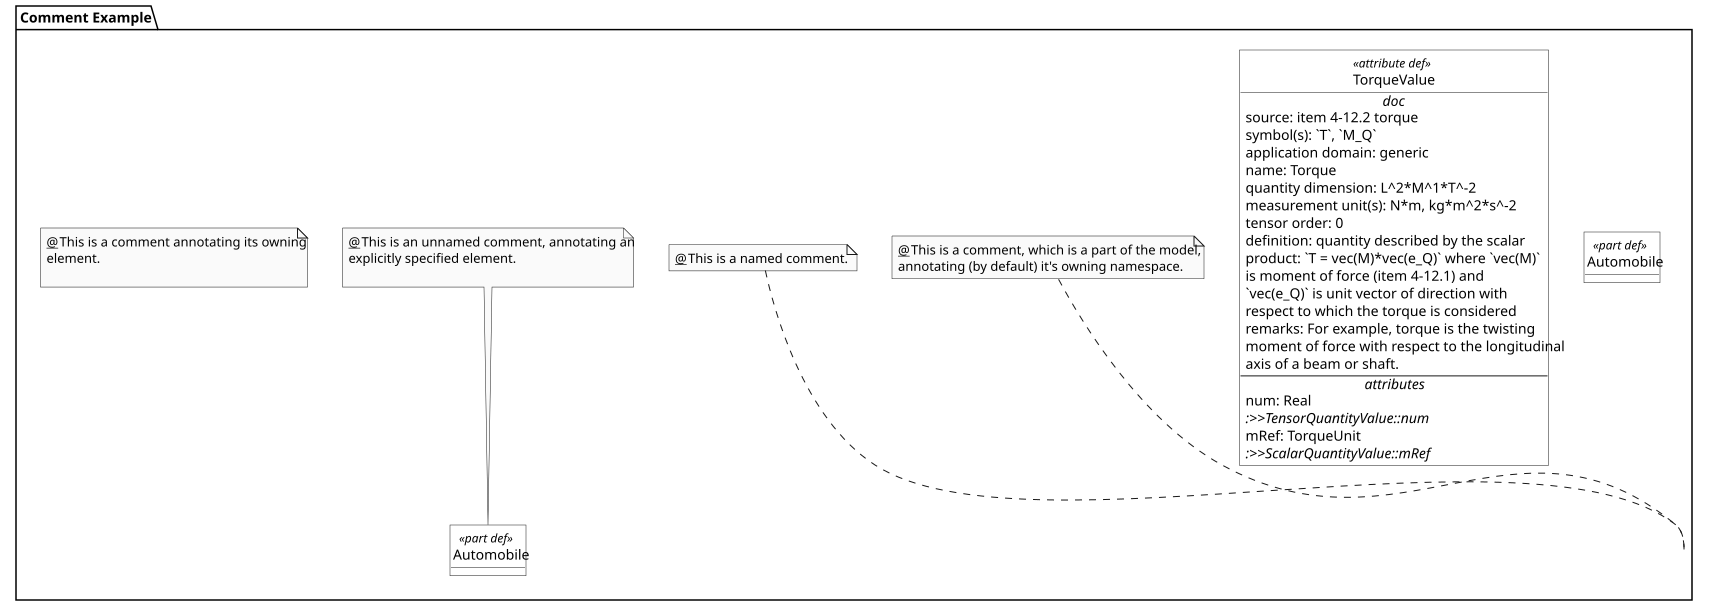

In [13]:
%viz "Comment Example"

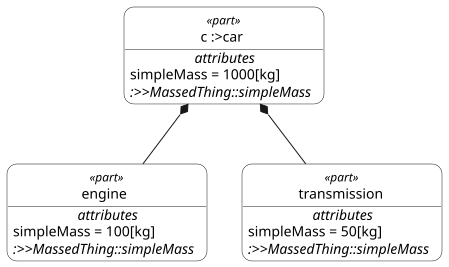

In [71]:
%viz --view=default --style=default "Car Mass Rollup Example 1::c"

In [79]:
package MassRollup1 {
	private import NumericalFunctions::*;
	
	part def MassedThing {
		attribute simpleMass :> ISQ::mass; 
		attribute totalMass :> ISQ::mass;
	}
	
	part simpleThing : MassedThing {
		attribute :>> totalMass = simpleMass;
	}
	
	part compositeThing : MassedThing {
		part subcomponents: MassedThing[*];		
		attribute :>> totalMass =
			simpleMass + sum(subcomponents.totalMass); 
	}
	
}

Package MassRollup1 (2906711b-3685-4aa2-899b-47c237e042a0)


In [89]:

	private import ScalarValues::*;
	private import MassRollup1::*;
	
	part def CarPart :> MassedThing {			
		attribute serialNumber: String;
	}
	
	part car: CarPart :> compositeThing {	
		attribute vin :>> serialNumber;
		
		part carParts: CarPart[*] :>> subcomponents;
		
		part engine :> simpleThing, carParts {
			//...
		}
		
		part transmission :> simpleThing, carParts {
			//...
		}
	}

	// Example usage
	
	private import SI::kg;
	part c :> car {
		attribute :>> simpleMass = 1000[kg];
		part :>> engine {
			attribute :>> simpleMass = 100[kg];
		}
		
		part redefines transmission {
			attribute :>> simpleMass = 50[kg];
		}	
	}
	
	// c::totalMass --> 1150.0[kg]


PartDefinition CarPart (75a3e83d-644b-48bc-873c-27468b87dbb8)
PartUsage car (4d28c990-cd43-42a7-9d0a-1c8580beec2e)
PartUsage c (58fc9895-a3ca-431c-8cf8-6e0902499bf2)


In [125]:
%eval c::totalMass

ERROR:Must be an accessible feature (use dot notation for nesting) (123.sysml line : 2 column : 1)
